[7.75574025e-02 2.31090300e-01 3.81406639e-01 5.28394636e-01
 6.71928574e-01 8.11865676e-01 9.48041915e-01 1.08026623e+00
 1.20831230e+00 1.33190625e+00 1.45070813e+00 1.56427313e+00
 1.67205902e+00 1.77273918e+00 1.86773386e+00 1.94003626e+00
 2.04263080e+00 2.05912165e+00 2.22977311e+00 2.23044696e+00
 2.45021987e+00 2.45023124e+00 2.70267402e+00 2.70267413e+00
 2.98427141e+00 2.98427141e+00 3.29343712e+00 3.29343712e+00
 3.62925513e+00 3.62925513e+00 3.99114731e+00 3.99114731e+00
 4.37872783e+00 4.37872783e+00 4.79172853e+00 4.79172853e+00
 5.22995714e+00 5.22995714e+00 5.69327227e+00 5.69327227e+00
 6.18156776e+00 6.18156776e+00 6.69476252e+00 6.69476252e+00
 7.23279360e+00 7.23279360e+00 7.79561152e+00 7.79561152e+00
 8.38317689e+00 8.38317689e+00 8.99545805e+00 8.99545805e+00
 9.63242927e+00 9.63242927e+00 1.02940695e+01 1.02940695e+01
 1.09803613e+01 1.09803613e+01 1.16912902e+01 1.16912902e+01
 1.24268442e+01 1.24268442e+01 1.31870130e+01 1.31870130e+01
 1.39717879e+01 1.397178

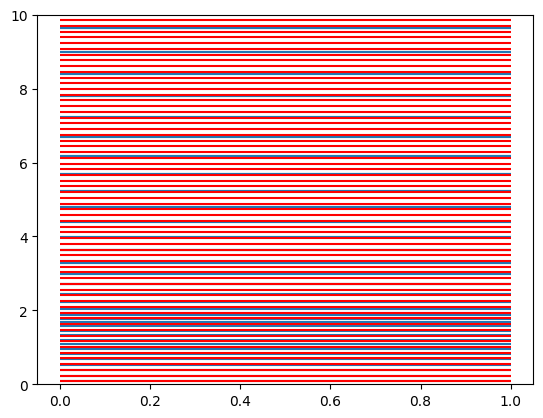

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x_max = 4

n_q = 8

N = 2**n_q

g = 1
beta_p = 1
beta_x = 1

x_max_op = g * ((N-1)/2) * np.sqrt(beta_p/beta_x) * np.sqrt(2 * np.pi / N)

x_max = x_max_op

j_array = np.arange(0, N)

delta_x = 2*x_max/(N-1)

x_eigenvalues = -x_max + delta_x*j_array

x_op = np.diag(x_eigenvalues)

delta_p = 2*np.pi/(delta_x * N)

p_max = np.pi/delta_x

p_eigenvalues = -p_max + delta_p * (j_array + 1/2)

p_diag = np.diag(p_eigenvalues)

omega = np.exp(-1j * 2 * np.pi / N)

ft = np.zeros((N,N), np.complex64)

for i in range(N):
    for j in range(N):
        #print(j+i)
        ft[i][j] = (1/np.sqrt(N)) * omega**(i*j)


ft_dag = np.conjugate(ft.T)

p_op = ft_dag @ p_diag @ ft


H = (g**2 * beta_p**2 )/2 * (p_op @ p_op) + beta_x**2 / (2* g**2) * (x_op @ x_op)

H_p = (g**2 * beta_p**2 )/2 * (p_op @ p_op)

d1 = np.diag(np.ones(N-1)*-1, k=-1) + np.diag(np.ones(N-1)*-1, k=1) + np.diag(np.ones(N)*2) 
d2 = np.zeros((N,N))
d2[N-1][0] = -1
d2[0][N-1] = -1

p2 = d1 + d2

H_p = (g**2 * beta_p**2 )/2 * p2

H = (g**2 * beta_p**2 )/2 * p2 + beta_x**2 / (2* g**2) * (x_op @ x_op)

H_x =  beta_x**2 / (2* g**2) * (x_op @ x_op)

eig_val, eig_vecs = np.linalg.eig(H)

sort_key = np.argsort(eig_val)

sorted_eigen_vecs = eig_vecs[sort_key]
print(eig_val[sort_key])
energies = np.real(eig_val)

plt.hlines(energies,0, 1)

plt.ylim(0,10)

real_energies = (np.min(energies)*2) * (j_array + 1/2)

print(energies)

plt.hlines(real_energies, 0, 1, color="red")


def proj_op(n_truc):

    proj = np.zeros((N, N), dtype = np.complex128)
    print(proj)
    for E_n in range(n_truc):
        
        proj = proj + np.outer(sorted_eigen_vecs[E_n], sorted_eigen_vecs[E_n])

    return proj




In [ ]:
import scipy as sp

def first_ord_trotter(r, T):
    dt = T / r

    U = sp.linalg.expm(-1j * dt * H_p) @ sp.linalg.expm(-1j * dt * H_x)

    U = np.linalg.matrix_power(U, r)
    
    return U

def second_ord_trotter(r, T):
    dt = T / r

    U = sp.linalg.expm(-1j * dt * H_x /2) @ sp.linalg.expm(-1j * dt * H_p) @ sp.linalg.expm(-1j * dt * H_x /2)

    U = np.linalg.matrix_power(U, r)
    
    return U

t = 1

exact_U = sp.linalg.expm(-1j * H * t)


def error(r, T):
    return sp.linalg.norm(exact_U - first_ord_trotter(r, T))

def error_proj(nval, r=100, T=1):
    return sp.linalg.norm((exact_U -  first_ord_trotter(r, T)) @ proj_op(nval))


def error2(r, T):
    return sp.linalg.norm(exact_U - second_ord_trotter(r, T))

r_list = np.arange(10,100)

errors = [error(r, t) for r in r_list]
errors2 = [error2(r, t) for r in r_list]


def commutator(A,B):
    return A@B - B@A

com_term = 0.5*np.linalg.norm(commutator(H_p, H_x))

com2 = commutator(H_p, H_x)

com_term2 = 1/12 * np.linalg.norm(commutator(H_x, com2)) + 1/24 * np.linalg.norm(commutator(H_p, com2))

plt.loglog(r_list, com_term/r_list, label = "first_ord_bound")
plt.loglog(r_list, com_term2/(r_list**2), label = "2nd order bound")
plt.loglog(r_list, errors, label = "first_ord_trotter")
plt.loglog(r_list, errors2)
plt.legend()


In [10]:
error_proj_list = []
nvals_list = []

x_error = error(100,1)

for i in range(N+1):
    error_proj_list.append(error_proj(i))
    nvals_list.append(i)

plt.axhline(x_error, ls = '--', color = "red", label = "Max 1st Order Error")
plt.plot(nvals_list, error_proj_list, color = "darkblue", label = "Subspace Projection")
plt.grid(True)
plt.xlabel(r"$n^*$")
plt.ylabel(r"$\mathcal{E}$")

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [

KeyboardInterrupt: 

array([[ 2., -1.,  0., ...,  0.,  0., -1.],
       [-1.,  2., -1., ...,  0.,  0.,  0.],
       [ 0., -1.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  2., -1.,  0.],
       [ 0.,  0.,  0., ..., -1.,  2., -1.],
       [-1.,  0.,  0., ...,  0., -1.,  2.]])